# Dimensionality Reduction

## The Curse of Dimensionality

In computational science, there is one big problem that has a tendency to plague all major programs and tasks: The curse of dimensionality. The idea is that as you add dimensions to your problem, the number of points for which you need to perform calculations grows exponentially.

One way to think of this in the simplest setting: For a dataset of $n$ observations with $p$ features, plot a simple scatterplot of every single pair of 2 features so you can review the relationship between them. This gives us ${p \choose 2} = \frac{p(p-1)}{2}$ scatter plots. So, if $p=2$, then its just 1 plot, then its 3, 6, 10, 15, 21, 28, 36, 45, and so on!

For another example, let's try picking grid points for a function, where each dimension is in $[0,1]$. For $f(x)$, you could pick just 100 evenly spaced $x$ values and calculate $f(0), f(0.01), f(0.02), ...$. For two variables, $f(x,y)$, then the same strategy would require you to calculate $f(0,0), f(0,0.01), f(0, 0.02), \dots, f(0.01, 0), f(0.01, 0.01), \dots$. This gives a total of $100\times 100 = 10,000$ points. This is still doable for a computer, But in 3 dimensions, you repeat the same process for $100^3 = 1,000,000$, and in 6 dimensions it becomes $1,000,000,000,000.

This is something that comes up often in our own statistical methods, so a big goal is to reduce dimensionality as much as possible. If we have $p$ features, then the question becomes "how many dimensions do we NEED to represent our problem accurately?"

The most common tool for this is **Principal Component Analysis**, or PCA, which we will discuss now!


## Principal Component Analysis (PCA)

PCA as a tool is quite complicated, so forgive us if we take this slowly. Let us write our features as $X_1, X_2, \dots, X_p$. A principal component, $Z_i$, is a linear combination of these features $Z_i = \phi_{1,i} X_1 + \phi_{2,i} X_2 + \dots + \phi_{p,i} X_p$, where we pick each $\phi$ such that $\sum_{j=1}^p \phi_{j,i}^2 = 1$, such that $Z_i$ has the $i$th largest variance possible, in order from largest to smallest. (This squared sum equalling 1 is important, because otherwise we could say $\phi_{j,i}^2 = 100$ is larger than if its 1, so just make it as big as possible)

Geometrically, it is doing something relatively simple: Rotating our coordinate system. For example, consider just two variables: $X_1$ and $X_2$. We could draw our $xy$ coordinates horizontally and vertically, but instead, what if we consider "In which direction does the data vary the most?" That direction becomes $Z_1$, and the *next* most varying direction (that is also perpendicular to $Z_1$) is $Z_2$.

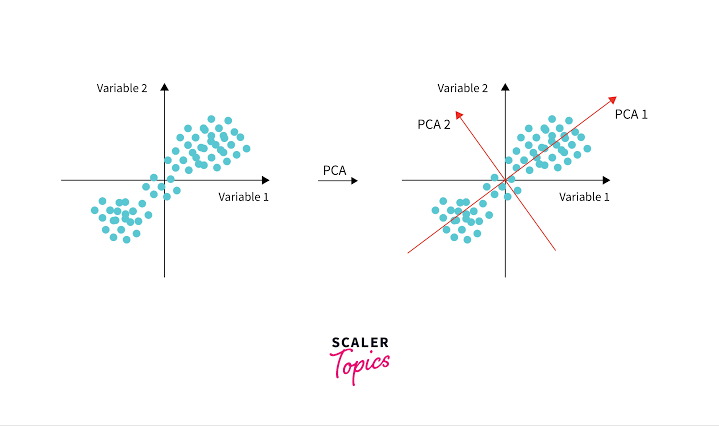

So, in two dimensions, PCA replaces $X_1$ and $X_2$ with $Z_1$ and $Z_2$. In higher dimensions, we do the same, and go until $Z_p$.

One other mathematical note: Before we apply PCA, we centre the data (such that the mean of EACH feature is 0). The reason for that is the usual scaling problem, but it also removes the mean from consideration when interpreting the results, which makes life a lot easier.

So, how does this help with dimensionality reduction?

Well, most of our problems can be reduced down to "how much variance do we want to capture to still accurately represent the data?" For example, if $Z_1$ represents 90% of the variance, and we only care about keeping 85%, we don't need $Z_2$ or anything beyond, reducing our problem to only 1 dimension.

As another example, let's say we have a dataset of height, weight, and blood pressure. Then, $Z_1$ is not any one of them, but a combination that tells us as much as possible in the minimum number of dimensions. It may be best called "overall health." We might find, then, that "overall health" is a great summary of how well a patient is doing, but $Z_2$, which may be "body size", which is useful, but not as useful.

So, PCA can be summarized in 3 steps:
1. Centre and standardize your data,
2. Find the directions in which the data varies the most, and
3. Keep only enough of those directions to explain the amount of info you need.

Of course, picking "how much variance you want to keep" is a HARD question, and one that goes well beyond this summary. Its a balance between computational time and data integrity, and can sometimes be very subjective without any one solid answer. For now, it may be best to say "I want to keep 95% of the variance." Time permitting, we may discuss more how to pick the right amount of data you need.

## Gaussian Mixture Models (GMM)

GMM is a probabilistic classification method that creates clusters by modeling data as a weighted sum of Gaussian distributions. This finds the probability of each data point belonging to each cluster and uses the mean and covariance to define the cluster shape.

For example:

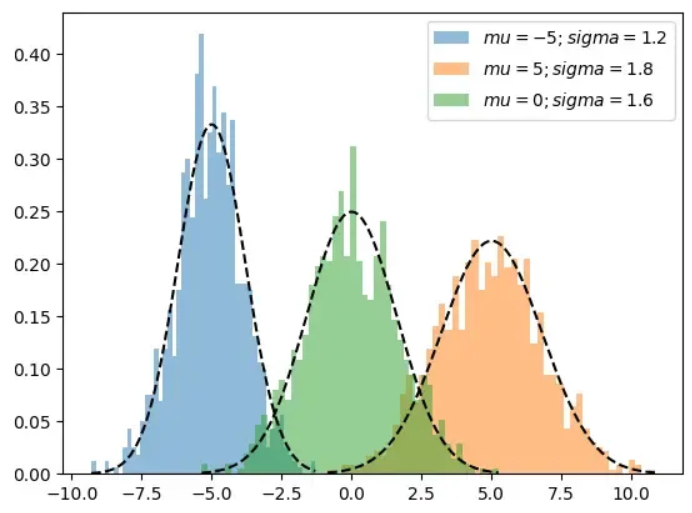

Each curve in this example represents a cluster, this is a probability density function defined as:

$p(x)=\sum_{k=1}^{K} \lambda_k \mathcal{N}\!\left(x \mid {\mu}_k, {\Sigma}_k\right)$


where:
*   $K$ are the clusters
*   $\lambda_k$ is the mixing weight
* $\mathcal{N}\!\left(x \mid {\mu}_k, {\Sigma}_k\right)$ is the D-variate Gaussian density
* $x\in\mathbb{R}^D$ is the data
* $\mu_k$ is the mean vector
* $\Sigma_k$ is the covariance matrix



The mixing weights $\lambda_k$ are probabilities such that:

$0\leq\lambda_k\leq1$ and $\sum_{k=1}^{K}\lambda_k=1$.


One of the benefits of GMM is that the probability of a sample $x$ belonging to a cluster $k$ can be evaluated for any cluster, this is the posterior probability:

$p(k \mid x) =
\frac{\lambda_k \, \mathcal{N}\!\left(x \mid \mu_k, \Sigma_k \right)}
{\sum_{j=1}^{K} \lambda_j \, \mathcal{N}\!\left(x \mid \mu_j, \Sigma_j \right)} \, $

The GMM model parameters $\mu_k$, $\Sigma_k$, and $\lambda_k$ are set to the best estimates with the **Expectation-Maximization (EM)** algorithm:

* **E-step (Expectation):** compute the posterior probability for each cluster, for each data point
* **M-Step (Maximization)**: use the posteriors from E-step to update the parameters

This starts with some initial setup of clusters (set by kmeans for example) and then goes back and forth between the E and M steps until the model is optimized.

## Bayesian Information Criterion (BIC)

The BIC is a statistical metric that can be used to select the best number of clusters $K$ for a GMM.

BIC score is:

$\mathrm{BIC}=-2\ln(L)+q\ln(n)$

This is made up of 2 terms:
* the "how good is the model" term $-2\ln(L)$, this is negative so the BIC goes down with a better model
* the "punishment for too much complexity or too large" term $q\ln(n)$, this is positive so the BIC score goes up with complexity

where:
* $L$ is the maximized likelihood function for the model (the probability of observing the data given the model)
* $q$ is the number of parameters in the model (this represents multiple things including the sum of cluster weights, means, and covariances).
* $n$ is the number of data points

The BIC is evaluated by making multiple GMM with different numbers of clusters $K$. The lowest BIC score corresponds to the best model configuration (a good balance between a good model and a not too complex model).

# Task - The Gauss Mystery Mathematician Prestigious Collectors Assembly (GMM PCA)

>Distinguished mathematicians have gathered for an evening celebrating the many languages of mathematics: geometry, computation, symmetry, patterns, and statistics.

>Each guest has arrived carrying a treasured artifact representing their favourite mathematician's work. As part of the evening's festivities, the Mathematical Society's newest invention — the Gauss Classification Engine — has recorded numerical measurements describing each artifact.

>Unfortunately, during the celebration, the name cards were separated from the artifacts!

**Can you help uncover the hidden groups within the collection and determine which artifact belongs to which distinguished mathematician?**

>*(As a reward for successfully finding the mathematicians that the artifacts represent, you will be awarded a commemorative model of the first-ever heptadecagon, a shape whose construction was famously solved by Gauss himself.)*

In [2]:
#Necessary Import Statements
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [3]:
import numpy as np
import pandas as pd

np.random.seed(42)

themes = [
    "geometry",
    "symmetry",
    "patterns",
    "computation",
    "statistics"
]

guests = {
    "Gauss":        [10, 6, 3, 2, 4],
    "Noether":      [5, 10, 3, 3, 3],
    "Lovelace":     [2, 3, 4, 10, 3],
    "Mirzakhani":   [10, 7, 10, 2, 4],
    "Ramanujan":    [3, 4, 10, 2, 3],
    "Nightingale":  [2, 3, 5, 6, 10]
}

artifacts = {
    "Gauss": "Constructible Heptadecagon Blueprint",
    "Noether": "Symmetry Conservation Mirror",
    "Lovelace": "Analytical Engine Algorithm Notes",
    "Mirzakhani": "Curved Surface Atlas",
    "Ramanujan": "Infinite Series Book Series",
    "Nightingale": "Statistical Rose Diagram"
}

n_per_guest = 200

latent_data = []
labels = []
artifact_names = []

for guest, center in guests.items():
  samples = np.random.normal(
      loc=center,
      scale=np.random.uniform(0.4,0.7),
      size=(n_per_guest, len(themes))
  )

  latent_data.append(samples)
  labels += [guest] * n_per_guest
  artifact_names += [artifacts[guest]] * n_per_guest

latent_data = np.vstack(latent_data)
labels = np.array(labels)

geometry = latent_data[:,0]
symmetry = latent_data[:,1]
patterns = latent_data[:,2]
computation = latent_data[:,3]
statistics = latent_data[:,4]

feature_names = {
    "shape_complexity": "Geometry",
    "curvature_measure": "Geometry",
    "transformation_score": "Symmetry",
    "invariance_score": "Symmetry",
    "repetition_frequency": "Patterns",
    "sequence_complexity": "Patterns",
    "algorithmic_depth": "Computation",
    "computational_cost": "Computation",
    "data_visualization": "Statistics",
    "uncertainty_analysis": "Statistics",
    "ink_density": "Artifact",
    "artifact_age": "Artifact"
}

X = pd.DataFrame({

    # Geometry measurements
    "shape_complexity":
        geometry + np.random.normal(0,0.2,len(geometry)),

    "curvature_measure":
        0.9*geometry + np.random.normal(0,0.2,len(geometry)),


    # Symmetry measurements
    "transformation_score":
        symmetry + np.random.normal(0,0.2,len(symmetry)),

    "invariance_score":
        0.9*symmetry + np.random.normal(0,0.2,len(symmetry)),


    # Pattern measurements
    "repetition_frequency":
        patterns + np.random.normal(0,0.2,len(patterns)),

    "sequence_complexity":
        0.9*patterns + np.random.normal(0,0.2,len(patterns)),


    # Computation measurements
    "algorithmic_depth":
        computation + np.random.normal(0,0.2,len(computation)),

    "computational_cost":
        0.9*computation + np.random.normal(0,0.2,len(computation)),


    # Statistics measurements
    "data_visualization":
        statistics + np.random.normal(0,0.2,len(statistics)),

    "uncertainty_analysis":
        0.9*statistics + np.random.normal(0,0.2,len(statistics)),


    # Two weak "artifact" measurements
    "ink_density":
        5 + 0.1*geometry + np.random.normal(0,0.05,len(geometry)),

    "artifact_age":
        300 + 2*patterns + np.random.normal(0,2,len(patterns))
})

cluster_to_theme = {}
cluster_to_guest = {}

scaler = StandardScaler()

clues_df = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

clue_key = pd.DataFrame(
    columns=["Cluster", "Clues", "Mathematician"]
)

#Answer Key
answer_key = pd.DataFrame({
    "Guest": labels,
    "Artifact": artifact_names
})

mystery_data = X.copy()

mystery_data.insert(
    0,
    "Artifact_ID",
    [f"A{i:03}" for i in range(len(X))]
)

mystery_data.head()

,Artifact_ID,shape_complexity,curvature_measure,transformation_score,invariance_score,repetition_frequency,sequence_complexity,algorithmic_depth,computational_cost,data_visualization,uncertainty_analysis,ink_density,artifact_age
0,A000,9.866027,8.369004,6.150439,5.750133,3.162172,2.952355,2.606528,1.917622,3.624983,3.211455,5.909456,310.456000
1,A001,9.769790,9.068870,5.725834,4.902156,2.566950,2.128391,0.905662,0.823289,4.665015,4.343996,5.881018,300.474616
2,A002,10.388847,9.153577,5.109239,4.902713,2.779845,2.630254,1.595519,1.651784,4.145035,2.891467,6.041094,307.130105
3,A003,9.096525,7.665525,5.575468,4.980158,3.647322,3.018170,3.033927,2.725595,4.130225,3.912975,5.826096,308.038108
4,A004,10.112511,9.277700,5.793365,5.234809,2.494305,2.303943,2.696778,2.264151,4.309436,3.475743,6.004553,306.468071


In [4]:
#Helper functions

#Plot GMM Clusters
def plot_gmm(clusters, X_scaled):
  #reduce data to 2D for visualization
  pca_vis = PCA(n_components=2)
  X_vis = pca_vis.fit_transform(X_scaled)

  plt.figure(figsize=(10,5))

  plt.scatter(
      X_vis[:,0],
      X_vis[:,1],
      c=clusters,
      cmap="viridis"
  )

  plt.title("GMM Clusters")

  plt.grid()
  plt.show()

#Plot PCA Variance
def plot_variance(cumulative_variance, variance_cutoff):
  plt.figure(figsize=(10,5))
  plt.plot(
      __builtins__.range(1, len(cumulative_variance)+1),
      cumulative_variance,
      marker="o"
  )

  plt.axhline(
      y=variance_cutoff,
      color="red",
      linestyle="--",
      label=f"Variance Cutoff: {variance_cutoff}"
  )

  plt.xlabel("Number of Principal Components (PCs)")
  plt.ylabel("Cumulative Explained Variance")
  plt.title("Total PCA Explained Variance")

  plt.grid()
  plt.show()

#Plot BIC Curve
def plot_BIC(bic, max_k):

    #Find best k
    best_k = np.argmin(bic) + 1

    plt.figure(figsize=(10,5))
    plt.plot(range(1, max_k), bic, marker="o")

    plt.axvline(
        x=best_k,
        color="red",
        linestyle="--",
        label=f"Best K: {best_k}"
    )

    plt.xlabel("Number of Clusters (K)")
    plt.ylabel("BIC Score")
    plt.title("BIC vs. Number of Clusters")

    plt.grid()
    plt.show()

def find_clues(clusters):

  global cluster_to_theme
  global cluster_to_guest
  global clue_key

  clues_df["Cluster"] = clusters

  clues_means = (
      clues_df
      .groupby("Cluster")
      .mean()
      )

  for cluster in clues_means.index:

    clues = (
        clues_means.loc[cluster]
        .sort_values(ascending=False)
        .index
        )
    themes = []

    for feature in clues:

      theme = feature_names[feature]

      if theme != "Artifact" and theme not in themes:
        themes.append(theme)

    print(f"\n=== Artifact Collection {cluster+1} ===")
    print("Clues:")

    for theme in themes[:2]:
      print("-", theme)

    cluster_to_theme[cluster] = themes[:2]

  answer_key["Cluster"] = clusters

  cluster_table = pd.crosstab(
      answer_key["Cluster"],
      answer_key["Guest"]
      )

  for cluster in cluster_table.index:
    counts = cluster_table.loc[cluster]

    if counts.max() / counts.sum() > 0.8:
      cluster_to_guest[cluster] = counts.idxmax()
    else:
      cluster_to_guest[cluster] = "Ambiguous cluster"

def solve_mystery(clue1, clue2):

    clue1 = clue1.lower()
    clue2 = clue2.lower()

    possible_clusters = set()

    for cluster, themes in cluster_to_theme.items():

        lowered = [t.lower() for t in themes]

        if clue1 in lowered and clue2 in lowered:
            return cluster_to_guest[cluster]

    return "No unique match found."

# Task 1 - Create a Gaussian Mixture Model

As usual we need to start with preprocessing.

In this case let's just do some standardization (this is required to use PCA later)

(Refer to the examples from scikit-learn or geeksforgeeks for help):



*   [geeksforgeeks Preprocessing](https://www.geeksforgeeks.org/machine-learning/data-pre-processing-wit-sklearn-using-standard-and-minmax-scaler/)
*   [scikit-learn StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)



In [5]:
#Standardize the data
#Create a scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Now we can build our first GMM and take a look!

(Refer to the examples from scikit-learn or geeksforgeeks for help):


*   [geeks for geeks GMM](https://www.geeksforgeeks.org/machine-learning/gaussian-mixture-model/)
*   [scikit-learn GMM](https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html)



In [6]:
#Create a GMM

gmm = GaussianMixture(
    n_components=3,
    covariance_type='full'
)

gmm.fit(X_scaled)
clusters = gmm.predict(X_scaled)

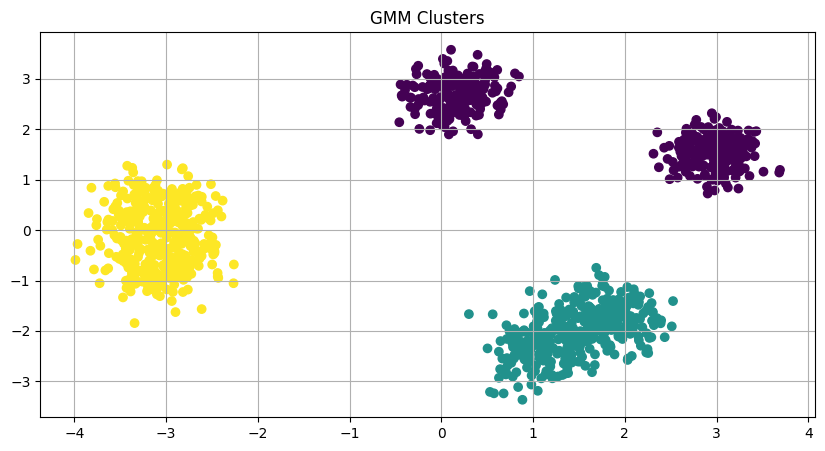

In [7]:
#Plot your clusters
#(This is a projection into 2D space for analysis)
plot_gmm(clusters, X_scaled)

# Task 2 - Apply Principal Component Analysis

>The Classification Engine recorded 12 measurements.

>Are all of them necessary to preserve enough information about the artifacts?

Now let's use PCA to compare the GMMs

(Refer to the examples from scikit-learn or geeksforgeeks for help):



*   [geeksforgeeks PCA](https://www.geeksforgeeks.org/machine-learning/implementing-pca-in-python-with-scikit-learn/)
*   [scikit-learn PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)

In [8]:
#Create a PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

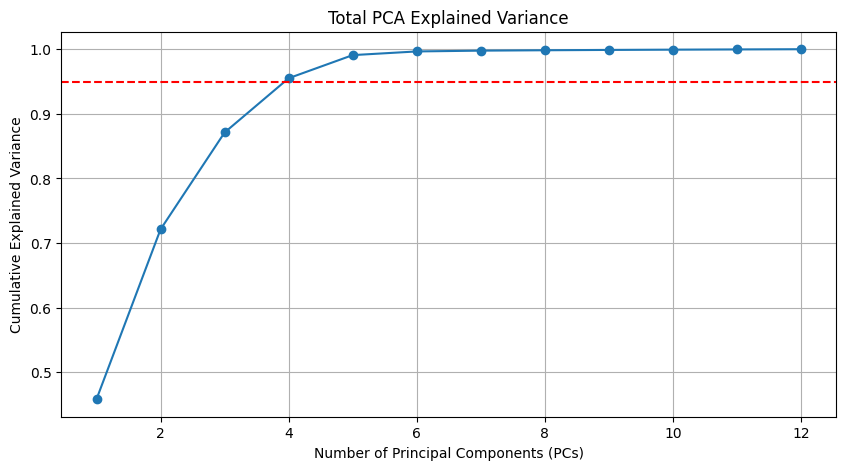

In [9]:
#Plot PCA cumulative variance

#Choose your variance threshold (0.95 for example)
variance_cutoff = 0.95

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

#You can build your own plots or use the helper function
plot_variance(cumulative_variance, variance_cutoff)

Next, choose the number of PCs you want to keep and reduce the dataset.

In [10]:
#Create a new PCA using your chosen number of n_components
components = 3

pca = PCA(n_components=components)
#X_pca = pca.fit_transform(X_scaled)

In [11]:
#Transform the dataset into a PCA reduced one

X_pca = pca.fit_transform(X_scaled)

Let's make another GMM using the PCA reduced dataset!

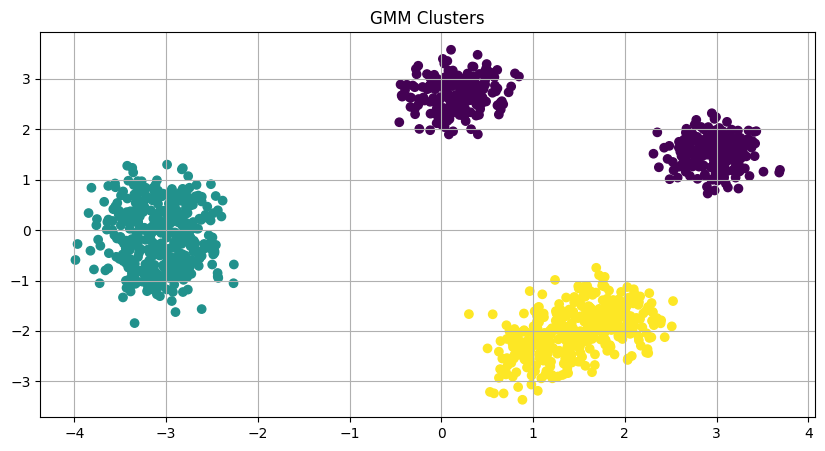

In [12]:
#Create a new gmm (use the same K as before)

gmm = GaussianMixture(
    n_components=3,
    covariance_type='full'
)

gmm.fit(X_pca)
clusters = gmm.predict(X_pca)

#Plot your clusters
#(This is a projection into 2D space for analysis)
plot_gmm(clusters, X_pca)

# Task 3 - Use BIC to find the best K clusters

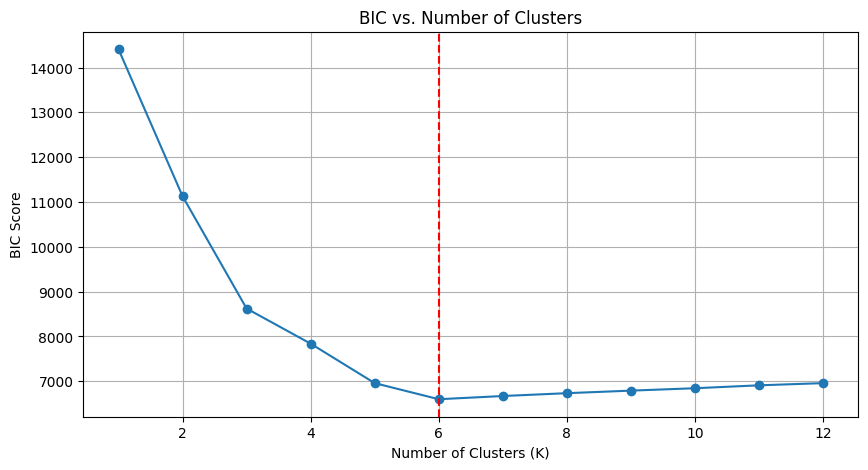

In [13]:
#Find the best K using BIC
bic = []

max_k = 13

#loop over test range of K
for k in range(1, max_k):
  gmm = GaussianMixture(
    n_components=k,
    covariance_type='full'
  )
  gmm.fit(X_pca)
  #FIT GMM (fit predict using X_pca)
  prediction = gmm.predict(X_pca)
  bic.append(gmm.bic(X_pca))

#Plot your BIC curve

#You can build your own plots or use the helper function
plot_BIC(bic, max_k)

Now let's create ANOTHER GMM using the best K!

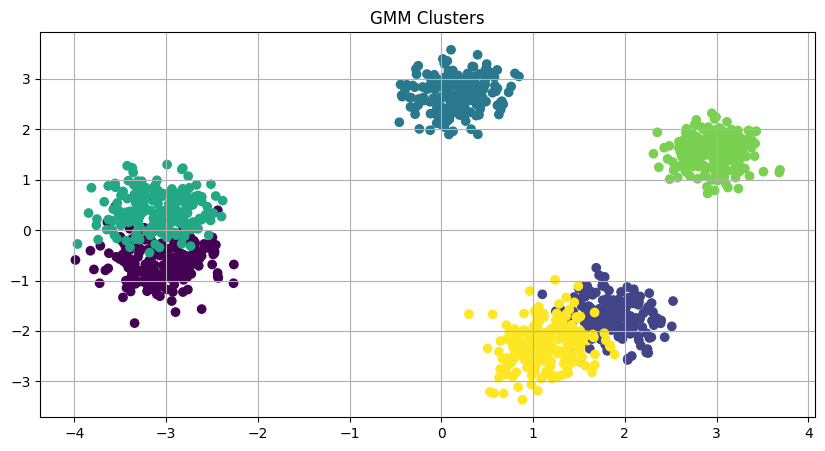

In [14]:
#Create a new gmm (use the best K)
gmm = GaussianMixture(
    n_components=np.argmin(bic) + 1,
    covariance_type='full'
  )
gmm.fit(X_pca)
clusters = gmm.predict(X_pca)

#Plot your clusters

plot_gmm(clusters, X_pca)

# Look for clues?

>Did you find the hidden groups within the collection?

>Submit your clusters into the Gauss Classification Engine to search for clues:

In [15]:
#Just run this line of code
find_clues(clusters)


=== Artifact Collection 1 ===
Clues:
- Computation
- Statistics

=== Artifact Collection 2 ===
Clues:
- Geometry
- Symmetry

=== Artifact Collection 3 ===
Clues:
- Patterns
- Symmetry

=== Artifact Collection 4 ===
Clues:
- Statistics
- Computation

=== Artifact Collection 5 ===
Clues:
- Patterns
- Geometry

=== Artifact Collection 6 ===
Clues:
- Symmetry
- Geometry


# Can you solve the mystery?

>For each Artifact Collection, submit your clues to discover the Mathematician!

In [16]:
#For each collection run (make sure to keep "")
solve_mystery("Geometry", "Symmetry")
solve_mystery("Patterns", "Symmetry")
solve_mystery("Patterns", "Geometry")
solve_mystery("Symmetry", "Geometry")
solve_mystery("Computation", "Statistics")

'Lovelace'

In [19]:
print(solve_mystery("Geometry", "Symmetry"))
print(solve_mystery("Patterns", "Symmetry"))
print(solve_mystery("Patterns", "Geometry"))
print(solve_mystery("Symmetry", "Geometry"))
print(solve_mystery("Computation", "Statistics"))

Gauss
Ramanujan
Mirzakhani
Gauss
Lovelace


# Questions:

1.   How many PCs did you choose?
2.  How does the first GMM you made (on the full original dataset) compare with the PCA reduced GMM?
3.  What best K (number of clusters) did BIC find?
4.  How does the best K GMM compare with the others?

(PS. the bonus questions make some really cool plots, check them out!)

# Congratulations!

>Through the use of GMM, PCA, and BIC, you have determined the mathematicians represented by artifacts at the celebration!

>The Mathematical Society awards you the honorary title:

>**Best In Clustering of the Gauss Mystery Mathematician Prestigious Collectors Assembly (BIC GMM PCA)**

>*(and presents you with a commemorative heptadecagon..)*

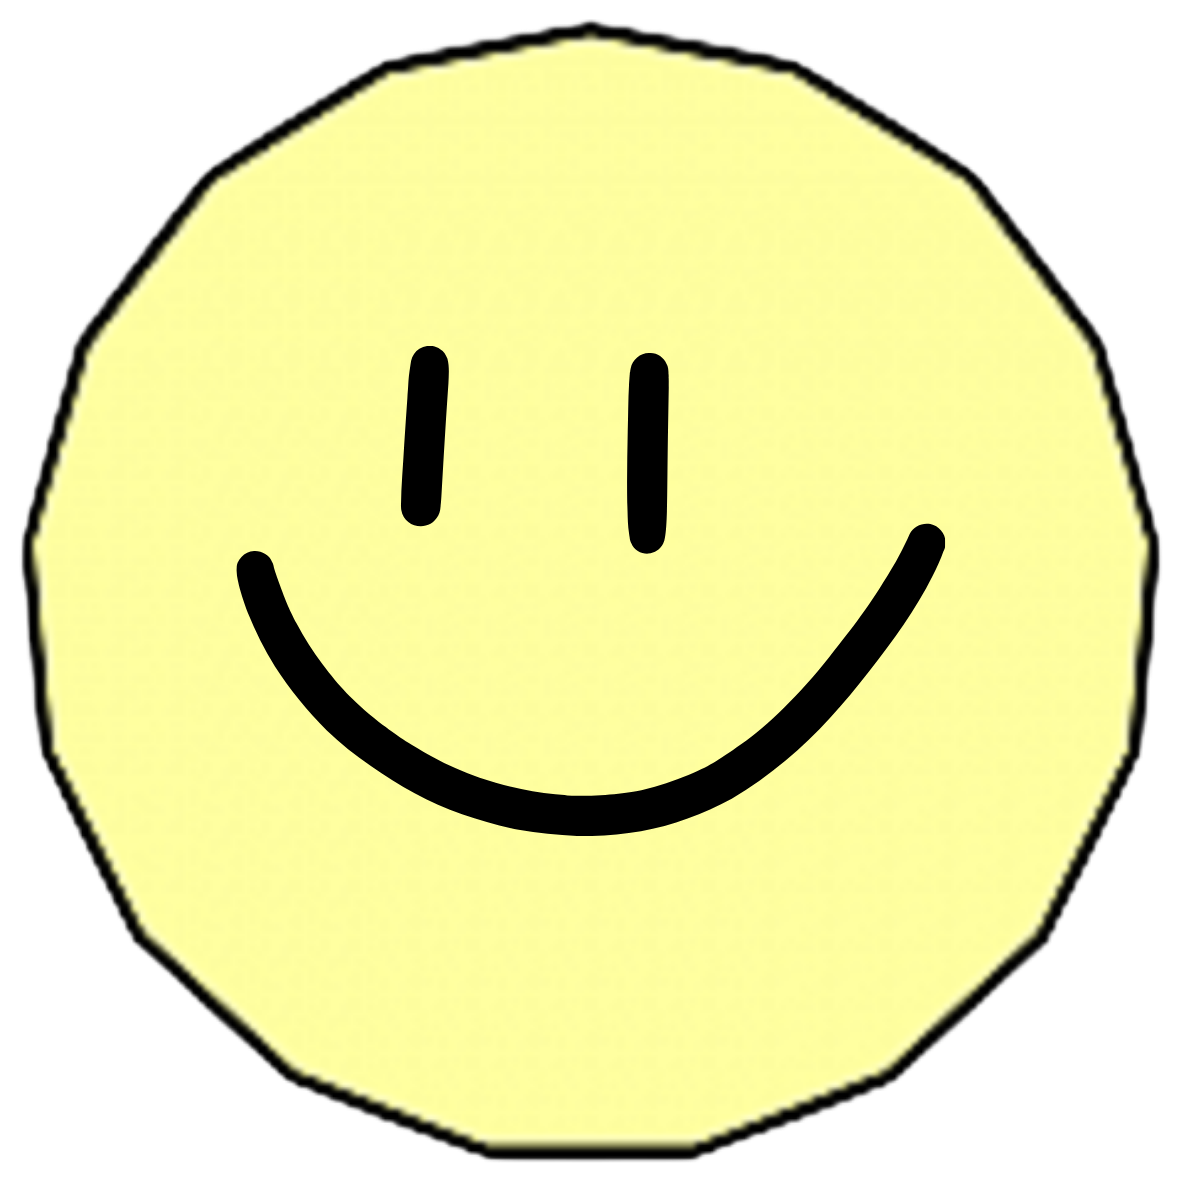

# BONUS - GMM Parameter Testing

First, let's compare covariance types to find the best BIC!

(Refer to the examples from scikit-learn or geeksforgeeks for help):


*   [geeks for geeks GMM](https://www.geeksforgeeks.org/machine-learning/gaussian-mixture-model/)
*   [scikit-learn GMM](https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html)

In [18]:
covariance_types = [
    "full",
    #SOMETHING,
    #SOMETHING,
    #SOMETHING
]

max_k = #MAX_CLUSTERS (try at least 10)

#loop over covariance_types
for cov in covariance_types:
  bic = []
  #loop over test range of K
  for k in range(1, max_k):
    #YOUR CODE HERE (use X_pca) build the gmm using (n_components=k) AND (covariance_type=cov)
    #FIT GMM
    bic.append(#BIC SCORE HERE)

  plt.plot(
      range(1,max_k),
      bic,
      marker="o",
      label=cov
    )

plt.xlabel("Number of Clusters (K)")
plt.ylabel("BIC")
plt.title("Effect of Covariance Type")

plt.legend()
plt.show()

SyntaxError: invalid syntax (528620914.py, line 8)

Next, let's compare different initial cluster setups for the EM algorithm

In [ ]:
init_methods = [
    "kmeans",
    #SOMETHING,
    #SOMETHING,
    #SOMETHING
]

max_k = #MAX_CLUSTERS (try at least 10)

for init in init_methods:
  bic = []
  #loop over test range of K
  for k in range(1, max_k):
    #build the gmm using (n_components= k)
    #AND (covariance_type = YOUR BEST COV TYPE)
    #AND (init_params = init)
    #FIT GMM
    bic.append(#BIC SCORE HERE)

  plt.plot(
      range(1,max_k),
      bic,
      marker="o",
      label=init
    )

plt.xlabel("Number of Clusters (K)")
plt.ylabel("BIC")
plt.title("Effect of Init Method")

plt.legend()
plt.show()

Now, let's test the number of random initial setups for the EM algorithm

In [ ]:
init_starts = [
    1,
    #SOMETHING,
    #SOMETHING,
    #SOMETHING
]

for n_starts in init_starts:
  bic = []
  #loop over test range of K
  for k in range(1, max_k):
    #YOUR CODE HERE (use X_pca)
    #build the gmm using (n_components= k)
    #AND (covariance_type = YOUR BEST COV TYPE)
    #AND (init_params = YOUR BEST INIT METHOD)
    #AND (n_init = n_starts)
    #FIT GMM
    bic.append(#BIC SCORE HERE)

  plt.plot(
      range(1,max_k),
      bic,
      marker="o",
      label=n_starts
    )

plt.xlabel("Number of Clusters (K)")
plt.ylabel("BIC")
plt.title("Effect of Init Runs")

plt.legend()
plt.show()

Finally, let's build your best GMM parameter tuned model and print it!

In [ ]:
#Create a new gmm

gmm = #SOMETHING
  #build the gmm using (n_components= YOUR BEST K)
  #AND (covariance_type = YOUR BEST COV TYPE)
  #AND (init_params = YOUR BEST INIT METHOD)
  #AND (n_init = YOUR BEST N_STARTS)

clusters = #SOMETHING (fit predict using X_pca)

#Plot your clusters
plot_gmm(clusters, X_pca)

# Bonus Questions:

1. What covariance type was the best?
2.  What init method was the best?
3.  How many initial starts was the best?
4.  How does your final parameter tuned GMM compare to the previous ones?